In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# load data set 
data = pd.read_csv("winequality.csv")
print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [8]:
print("Dataset size = ",data.shape)
print("Columns = ",data.columns)
print("Missing Values ",data.isnull().sum())

# features and target
X = data.drop('quality',axis=1) # feature 11 col
y = data['quality'] # target

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Dataset size =  (1599, 12)
Columns =  Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')
Missing Values  fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [ ]:
# apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print("Variance Radio = ",pca.explained_variance_ratio_)
print("Total Variance Explained = ",sum(pca.explained_variance_ratio_))

Variance Radio =  [0.28173931 0.1750827 ]
Total Variance Explained =  0.4568220118429404


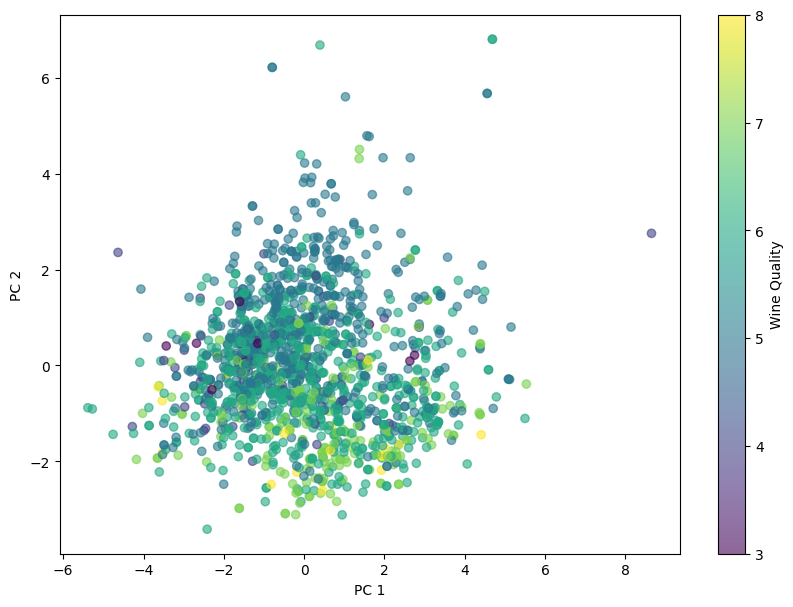

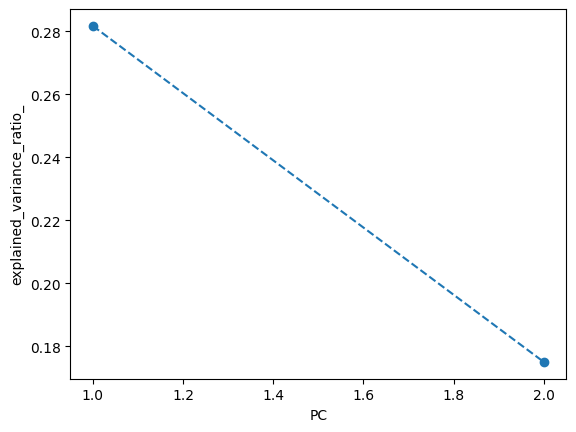

In [18]:
plt.figure(figsize=(10,7))
scatter = plt.scatter(X_pca[:, 0],X_pca[:, 1],c=y,cmap='viridis',alpha=0.6)
plt.colorbar(scatter,label="Wine Quality")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title=("PCA of wine Quality")
plt.show()

# Scree Plot -> Variance per component
plt.plot(range(1,3),pca.explained_variance_ratio_,marker="o",linestyle="--")
plt.xlabel("PC")
plt.ylabel("explained_variance_ratio_")
plt.title=("Scree Plot")
plt.show()



In [21]:
# train a classification after PCA
X_train , X_test , y_train , y_test = train_test_split(X_pca,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy PCA = ",accuracy)

# Compare with original features
X_train_o , X_test_o , y_train_o , y_test_o = train_test_split(X_scaled,y,test_size=0.2,random_state=42)
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train_o,y_train)
y_pred_o = clf.predict(X_test_o)
accuracy_o = accuracy_score(y_test_o,y_pred_o)
print("original Accuracy = ",accuracy_o)

Accuracy PCA =  0.5375
original Accuracy =  0.65
